# EDA and Normal Behaviour

This notebook explores the structure and behaviour of the CATS time series before anomaly-detection models are developed.

The analysis focuses on understanding:

- the normal operating behaviour of the system;
- the behaviour and scale of the 17 signals;
- relationships between signals;
- temporal patterns;
- potential trends, variability, and dependencies;
- differences between the nominal and later evaluation periods.

The first 1,000,000 observations are treated as the nominal period for understanding normal behaviour, based on the official CATS dataset documentation.

No anomaly-detection model will be trained in this notebook.

In [1]:
from pathlib import Path
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

# Raw CATS data
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cats" / "data.parquet"
METADATA_PATH = PROJECT_ROOT / "data" / "raw" / "metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Data file:", DATA_PATH)
print("Metadata file:", METADATA_PATH)

Project root: c:\Users\ADEGOKE\Desktop\CATS
Data file: c:\Users\ADEGOKE\Desktop\CATS\data\raw\cats\data.parquet
Metadata file: c:\Users\ADEGOKE\Desktop\CATS\data\raw\metadata.csv


## Step 1 — Define the Nominal Period

The official CATS documentation identifies the first 1,000,000 observations as nominal.

This period will be used to examine normal system behaviour before analysing the later observations containing anomalous segments.

In [2]:
import pandas as pd

df = pd.read_parquet(DATA_PATH)

nominal_df = df.iloc[:1_000_000].copy()

print("Total observations:", len(df))
print("Nominal observations:", len(nominal_df))
print("Nominal start:", nominal_df.index[0])
print("Nominal end:", nominal_df.index[-1])

Total observations: 5000000
Nominal observations: 1000000
Nominal start: 2023-01-01 00:00:00
Nominal end: 2023-01-12 13:46:39


### Conclusion

The first 1,000,000 observations form the nominal period, covering:

- Start: `2023-01-01 00:00:00`
- End: `2023-01-12 13:46:39`

This period will serve as the reference for understanding normal system behaviour before developing and evaluating anomaly detectors.

## Step 2 — Nominal Signal Statistics

Before examining relationships or temporal patterns, we need to understand the basic numerical behaviour of each signal during the nominal period.

We will examine the minimum, maximum, mean, and standard deviation of the 17 system signals.

These statistics describe the normal scale and variability of each signal.

In [5]:
signal_columns = [
    column
    for column in nominal_df.columns
    if column not in ["y", "category"]
]

print("Number of signal columns:", len(signal_columns))
print(signal_columns)

Number of signal columns: 17
['aimp', 'amud', 'arnd', 'asin1', 'asin2', 'adbr', 'adfl', 'bed1', 'bed2', 'bfo1', 'bfo2', 'bso1', 'bso2', 'bso3', 'ced1', 'cfo1', 'cso1']


In [8]:
signal_summary = nominal_df[
    [
        "aimp", "amud", "arnd", "asin1", "asin2",
        "adbr", "adfl", "bed1", "bed2", "bfo1",
        "bfo2", "bso1", "bso2", "bso3", "ced1",
        "cfo1", "cso1"
    ]
].describe().T[
    ["min", "max", "mean", "std"]
]

print(signal_summary)

             min          max        mean         std
aimp    0.000000     1.000000    0.010102    0.100000
amud  -37.000000    30.000000   -2.864081    9.831507
arnd   10.000000    50.000000   21.574429   10.634474
asin1  -1.000000     1.000000    0.029595    0.699864
asin2  -1.000000     1.000000    0.002564    0.707854
adbr    0.000000     1.000000    0.498540    0.499998
adfl    0.000000     1.000000    0.603450    0.489181
bed1    0.000000     6.068269    1.010185    0.710263
bed2    0.000000     3.468064    0.202040    0.321454
bfo1    0.000000    49.368941   10.929098   11.343483
bfo2    0.000000    78.075280   45.462342   11.997139
bso1  -37.918300    31.074949   -2.861104    9.879527
bso2   -0.745882     1.913420    0.603451    0.684067
bso3    0.000000     0.590806    0.300441    0.098176
ced1    0.000000  1107.280556  383.518693  137.641448
cfo1  -72.237749    32.293983  -10.785074   14.315489
cso1  -20.445898    87.932202   43.200936   15.719292


### Conclusion

The 17 system signals have substantially different numerical scales and levels of variability during the nominal period.

For example, `aimp` ranges from 0 to 1, while `ced1` ranges from 0 to approximately 1,107. Other signals contain both positive and negative values.

This confirms that the signals should not be interpreted using a single absolute threshold or a common numerical scale.

The observed ranges are treated as characteristics of the nominal period at this stage; they are not assumed to represent anomalies.

## Step 3 — Visual Inspection of Nominal Signals

Summary statistics describe the scale and variability of the signals, but they do not show how the signals behave over time.

We will therefore visualize a small selection of signals from the nominal period.

The purpose is to look for:

- stable behaviour;
- oscillations;
- trends;
- changes in variability;
- unusual movements within the nominal period.

This is an exploratory visual check only. No anomaly labels are used to select or interpret the observations.

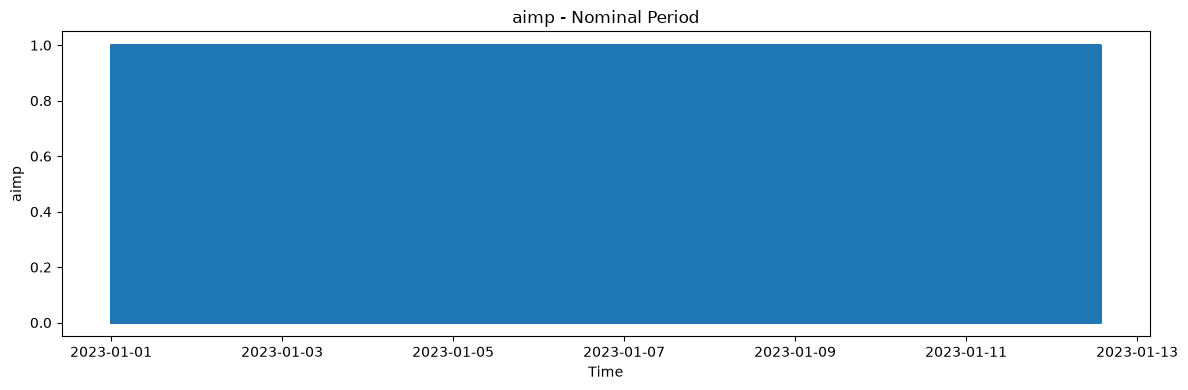

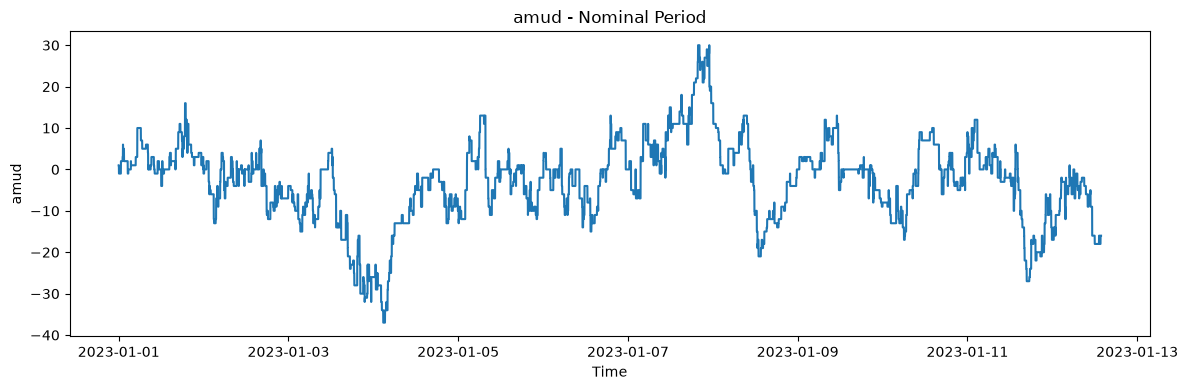

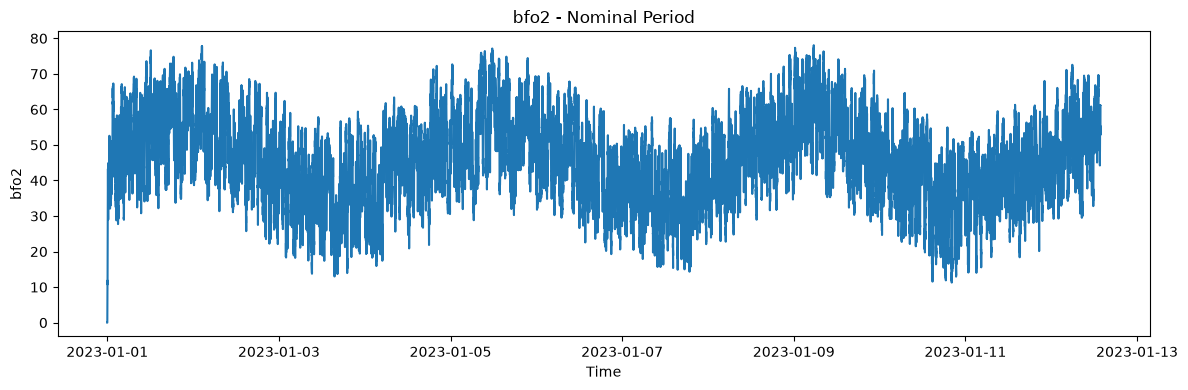

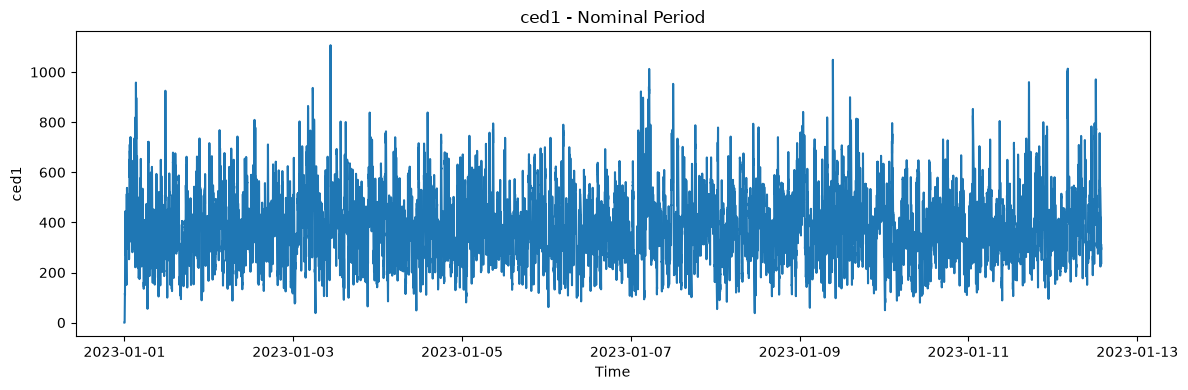

In [10]:
import matplotlib.pyplot as plt

signals_to_plot = ["aimp", "amud", "bfo2", "ced1"]

for signal in signals_to_plot:
    plt.figure(figsize=(12, 4))
    plt.plot(nominal_df.index, nominal_df[signal])
    plt.title(f"{signal} - Nominal Period")
    plt.xlabel("Time")
    plt.ylabel(signal)
    plt.tight_layout()
    plt.show()

### Conclusion

The visual inspection shows that the CATS signals exhibit substantially different normal behaviours.

- `aimp` is bounded between 0 and 1 and has very low average activity during the nominal period. The dense plot is difficult to interpret at the full 1,000,000-observation resolution, so its apparent filled appearance should not be interpreted as a constant value.
- `amud` shows substantial short-term variability around both negative and positive values.
- `bfo2` shows substantial variability across a broad numerical range, with possible slower temporal structure that will require further analysis.
- `ced1` exhibits very high variability and large numerical fluctuations even during the nominal period.

These observations reinforce that anomaly detection cannot rely on a single absolute threshold across all signals. Normal variability differs substantially between channels.

Further temporal analysis will be used to determine whether apparent trends, cycles, or other dependencies are actually present.

## Step 4 — Examine Temporal Behaviour at Lower Resolution

The full nominal period contains 1,000,000 observations, making direct visualization difficult.

To examine broader temporal behaviour, we will temporarily sample one observation every 1,000 seconds.

This does not modify the original data. It is only a visualization technique for identifying broad trends, oscillations, or changes in behaviour over time.

In [12]:
nominal_sample = nominal_df.iloc[::1000]

print("Original nominal observations:", len(nominal_df))
print("Sample observation:", len(nominal_sample))

Original nominal observations: 1000000
Sample observation: 1000


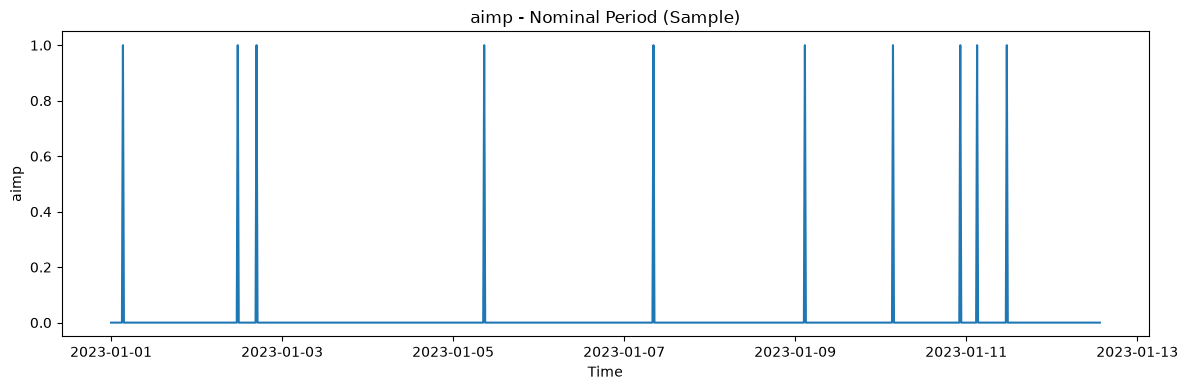

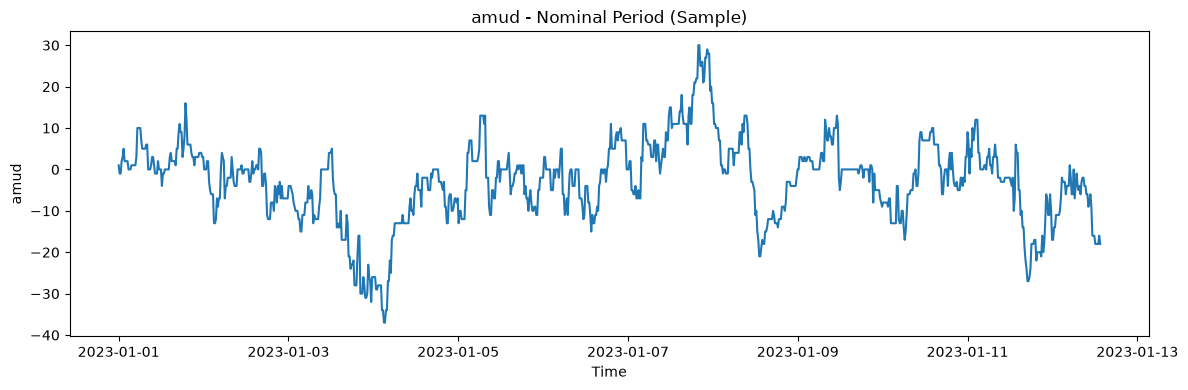

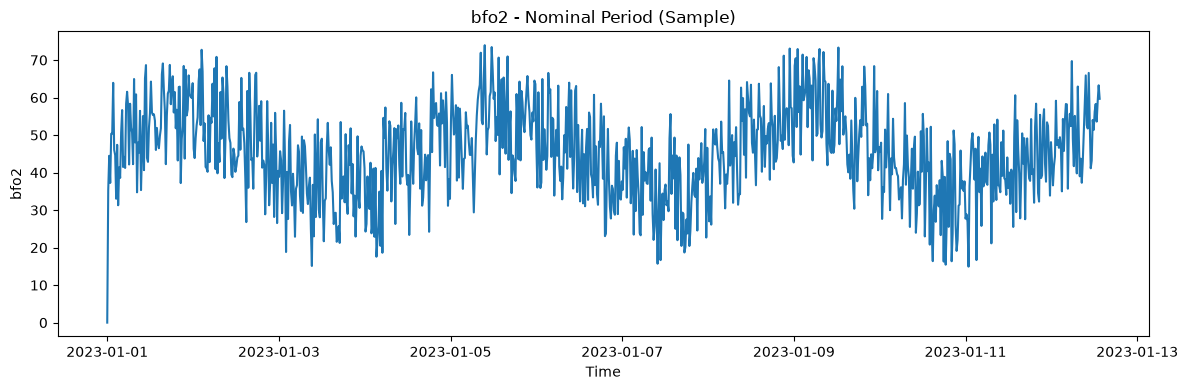

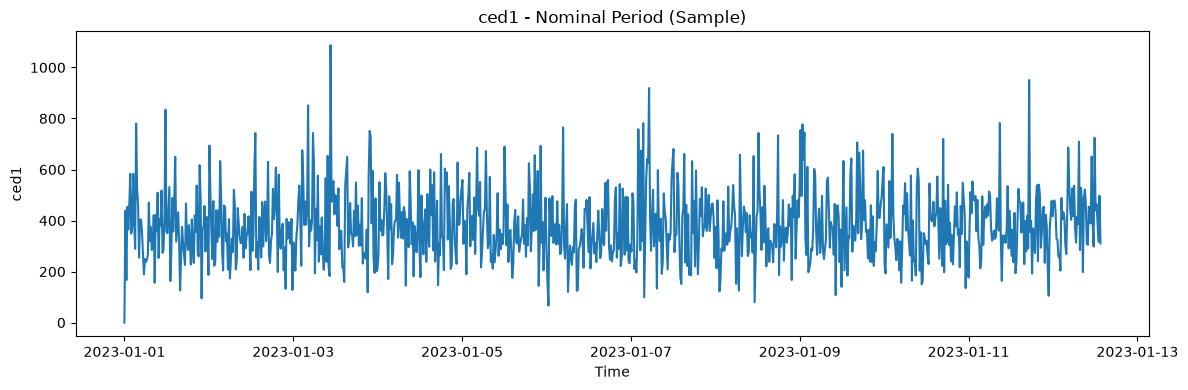

In [15]:
signals_to_plot = ["aimp", "amud", "bfo2", "ced1"]

for signal in signals_to_plot:
    plt.figure(figsize=(12, 4))
    plt.plot(nominal_sample.index, nominal_sample[signal])
    plt.title(f"{signal} - Nominal Period (Sample)")
    plt.xlabel("Time")
    plt.ylabel(signal)
    plt.tight_layout()
    plt.show()

### Conclusion

The sampled temporal plots provide a clearer view of how different signals behave over the nominal period.

- `aimp` is predominantly at 0, with occasional short-duration transitions to 1.
- `amud` shows substantial irregular variability around both negative and positive values, without an obvious persistent trend.
- `bfo2` shows high short-term variability across a broad range, with possible slower temporal structure that requires further analysis.
- `ced1` shows very high short-term variability and large fluctuations, including values above 1,000, while showing no obvious persistent long-term trend.

These observations confirm that normal behaviour differs substantially between signals. Some signals are relatively sparse or bounded, while others exhibit continuous high variability.

The apparent temporal patterns identified here are exploratory observations only. Further analysis is required before determining whether the signals contain genuine trends, periodicity, or other temporal dependencies.

## Step 5 — Relationships Between Signals

CATS is a multivariate time series, so the signals should not be considered independently.

We will examine the correlation between the 17 signals during the nominal period.

Correlation provides an initial indication of whether pairs of signals tend to move together during normal operation.

This is exploratory analysis only. Correlation does not establish causation or determine whether two signals are functionally related.

In [16]:
correlation_matrix = nominal_df[signal_columns].corr()

print(correlation_matrix.round(2))

       aimp  amud  arnd  asin1  asin2  adbr  adfl  bed1  bed2  bfo1  bfo2  \
aimp   1.00  0.00 -0.00   0.00  -0.00  0.00  0.00  0.14  0.31 -0.00 -0.00   
amud   0.00  1.00  0.03   0.06   0.03 -0.01 -0.00  0.00  0.00  0.01  0.02   
arnd  -0.00  0.03  1.00   0.14   0.04  0.03  0.00 -0.01 -0.00  0.50  0.14   
asin1  0.00  0.06  0.14   1.00  -0.01  0.00  0.00  0.01  0.00  0.06  0.61   
asin2 -0.00  0.03  0.04  -0.01   1.00 -0.01  0.00 -0.01 -0.00  0.00 -0.01   
adbr   0.00 -0.01  0.03   0.00  -0.01  1.00 -0.00  0.00  0.00  0.65  0.35   
adfl   0.00 -0.00  0.00   0.00   0.00 -0.00  1.00  0.01  0.01  0.00  0.03   
bed1   0.14  0.00 -0.01   0.01  -0.01  0.00  0.01  1.00  0.74 -0.01 -0.00   
bed2   0.31  0.00 -0.00   0.00  -0.00  0.00  0.01  0.74  1.00 -0.00 -0.00   
bfo1  -0.00  0.01  0.50   0.06   0.00  0.65  0.00 -0.01 -0.00  1.00  0.47   
bfo2  -0.00  0.02  0.14   0.61  -0.01  0.35  0.03 -0.00 -0.00  0.47  1.00   
bso1   0.00  1.00  0.03   0.06   0.10 -0.01 -0.00  0.00  0.00  0.01  0.02   

### Conclusion

The correlation analysis shows that the 17 CATS signals are not independent during the nominal period.

Several signal pairs exhibit substantial positive or negative correlation, while many other pairs have weak or near-zero correlation. For example, `bed1` and `bed2` have a correlation of approximately 0.74, while `bfo1` and `cfo1` have a correlation of approximately -0.70.

This indicates that normal system behaviour includes relationships between multiple signals.

These dependencies may be useful for multivariate anomaly detection because an abnormal observation may involve a change in the relationship between signals rather than an extreme value in a single signal.

Correlation alone does not establish causation or determine the physical meaning of these relationships.

## Step 6 — Temporal Dependence

Anomaly detection for time-series data should consider how observations behave over time.

We will examine whether each signal shows dependence on its recent past by calculating the lag-1 autocorrelation during the nominal period.

A lag of 1 compares each observation with the immediately preceding observation.

This is an exploratory analysis of temporal dependence and does not involve anomaly labels.

In [17]:
lag1_autocorrelation = nominal_df[signal_columns].corrwith(
    nominal_df[signal_columns].shift(1)
)

print(lag1_autocorrelation.sort_values(ascending=False).round(3))

asin1    1.000
asin2    1.000
bso1     1.000
cso1     1.000
bso3     1.000
bfo2     1.000
cfo1     1.000
ced1     1.000
amud     1.000
bfo1     1.000
arnd     1.000
bso2     0.997
bed1     0.990
adbr     0.990
adfl     0.953
bed2     0.950
aimp     0.001
dtype: float64


### Conclusion

The lag-1 autocorrelation analysis shows strong temporal dependence in most CATS signals during the nominal period.

Eleven signals have a displayed lag-1 autocorrelation of 1.000, while `bso2`, `bed1`, `adbr`, `adfl`, and `bed2` also show strong temporal dependence. In contrast, `aimp` has a lag-1 autocorrelation of approximately 0.001, indicating essentially no linear dependence on its immediately preceding value.

These results show that temporal context is important for understanding normal system behaviour. Anomaly detection should therefore consider how a signal behaves relative to its recent history rather than relying only on isolated observations.

The lag-1 autocorrelation results are exploratory and do not by themselves determine which detection method will perform best.

## Step 7 — Distribution Shape

Summary statistics showed that the CATS signals have very different numerical ranges and variability.

We will now examine the skewness of each signal during the nominal period.

Skewness helps identify whether a signal's distribution is approximately symmetric or whether observations are concentrated toward one side of the distribution.

This is important because highly skewed signals may require different statistical treatment when developing later anomaly detectors.

This analysis uses only the nominal period and does not use anomaly labels.

In [20]:
nominal_skewness = nominal_df[signal_columns].skew()

print(nominal_skewness.sort_values(ascending=False).round(3))

aimp     9.798
bed2     2.099
bfo1     1.160
arnd     0.969
bed1     0.920
ced1     0.582
bso3     0.053
adbr     0.006
asin2   -0.008
bfo2    -0.036
asin1   -0.086
bso2    -0.196
amud    -0.342
bso1    -0.352
adfl    -0.423
cso1    -0.424
cfo1    -0.513
dtype: float64


### Conclusion

The nominal signal distributions have substantially different degrees and directions of skewness.

`aimp` is extremely right-skewed, while `bed2`, `bfo1`, `arnd`, and `bed1` are also noticeably right-skewed. Several other signals are approximately symmetric, while `cfo1`, `cso1`, `adfl`, `bso1`, and `amud` show mild to moderate left skewness.

This indicates that the CATS signals do not share a common distributional shape.

Therefore, later statistical anomaly detectors should not assume that all signals follow the same symmetric or Gaussian distribution. The distributional characteristics of individual signals will need to be considered when establishing normal-behaviour thresholds.

## Step 8 — Nominal Quantiles

Minimum and maximum values show the extremes of a signal, but they do not show how frequently those extremes occur.

We will therefore examine selected quantiles of each signal during the nominal period.

The 1st, 25th, 50th, 75th, and 99th percentiles will help describe the typical range and the upper and lower tails of normal behaviour.

This is important because a large maximum value may be a normal but relatively rare observation rather than an anomaly.

This analysis uses only the nominal period and does not use anomaly labels.

In [21]:
nominal_quantiles = nominal_df[signal_columns].quantile(
    [0.01, 0.25, 0.50, 0.75, 0.99]
).T

print(nominal_quantiles.round(3))

          0.01     0.25     0.50     0.75     0.99
aimp     0.000    0.000    0.000    0.000    1.000
amud   -30.000   -8.000   -2.000    3.000   22.000
arnd    10.030   12.886   17.827   28.103   49.001
asin1   -0.999   -0.672    0.082    0.715    0.999
asin2   -1.000   -0.707    0.008    0.710    1.000
adbr     0.000    0.000    0.000    1.000    1.000
adfl     0.000    0.000    1.000    1.000    1.000
bed1     0.020    0.452    0.904    1.428    3.090
bed2     0.000    0.001    0.035    0.277    1.353
bfo1     0.000    0.817    8.679   16.357   45.336
bfo2    18.906   37.068   45.492   54.001   71.268
bso1   -30.760   -8.463   -1.865    2.863   21.882
bso2    -0.634    0.013    0.706    1.135    1.796
bso3     0.090    0.228    0.300    0.371    0.518
ced1   123.620  285.195  371.129  468.885  757.693
cfo1   -49.148  -19.520   -9.200   -0.568   17.997
cso1    -0.544   33.659   43.925   54.140   74.691


### Conclusion

The nominal quantiles show that the 17 signals have substantially different typical ranges and tail behaviour.

For example:

- `aimp` has a median and 75th percentile of `0`, while its 99th percentile is `1`, confirming that it is mostly inactive with occasional high values.
- `amud` has a median of `-2` and a 1st–99th percentile range of approximately `-30` to `22`.
- `bfo2` is concentrated around a median of approximately `45.5`, with 1st and 99th percentiles of approximately `18.9` and `71.3`.
- `ced1` has a much larger numerical scale, with a median of approximately `371.1` and a 99th percentile of approximately `757.7`.
- `bed2` has a median close to zero but a substantially larger upper tail, consistent with its strong positive skewness.

These results show that the normal operating range is highly signal-specific. In particular, the 99th percentile is substantially different from the maximum for several signals, demonstrating that extreme values can occur within the nominal period.

Therefore, later anomaly-detection methods should establish normal behaviour separately for each signal rather than applying a common numerical threshold across all channels.

## Step 9 — Stability of Nominal Behaviour

The first 1,000,000 observations are identified by the CATS documentation as nominal.

However, nominal behaviour may still change over time.

We will therefore compare summary statistics between the beginning and end of the nominal period.

The purpose is to determine whether the typical level and variability of the signals remain reasonably stable during the nominal period.

This analysis does not use anomaly labels.

In [22]:
nominal_start = nominal_df.iloc[:100_000]
nominal_end = nominal_df.iloc[-100_000:]

stability_comparison = pd.DataFrame({
    "start_mean": nominal_start[signal_columns].mean(),
    "end_mean": nominal_end[signal_columns].mean(),
    "start_std": nominal_start[signal_columns].std(),
    "end_std": nominal_end[signal_columns].std()
})

print(stability_comparison.round(3))

       start_mean  end_mean  start_std  end_std
aimp        0.010     0.010      0.100    0.102
amud        2.216   -10.040      4.586    7.674
arnd       21.153    20.471     11.061    9.426
asin1       0.708     0.126      0.305    0.517
asin2       0.030    -0.054      0.700    0.721
adbr        0.499     0.502      0.500    0.500
adfl        0.611     0.602      0.488    0.490
bed1        1.010     1.045      0.727    0.710
bed2        0.202     0.209      0.325    0.329
bfo1       10.623    10.441     11.109   10.389
bfo2       52.610    46.498     10.547    9.748
bso1        2.247   -10.091      4.517    7.782
bso2        0.611     0.602      0.684    0.687
bso3        0.303     0.303      0.100    0.085
ced1      383.872   399.686    142.507  138.475
cfo1       -5.344   -17.498     11.886   11.467
cso1       55.430    37.060     11.591   12.928


### Conclusion

The comparison between the beginning and end of the nominal period shows that normal system behaviour is not perfectly constant over time.

Several signals remain relatively stable in both mean and standard deviation, while others show noticeable changes in their average level or variability. For example, `amud`, `bso1`, `asin1`, `bfo2`, `cfo1`, and `cso1` show meaningful changes between the two portions of the nominal period.

These changes should not be interpreted as anomalies because both periods are part of the documented nominal data.

Instead, the results indicate that normal system behaviour can vary over time. This is important for anomaly detection because a detector that assumes a fixed normal distribution may generate false alarms when normal operating conditions change.

The observed temporal variation will therefore be considered when developing and evaluating the anomaly detectors.

## Step 10 — Verify the Nominal Labels

The CATS documentation identifies the first 1,000,000 observations as nominal.

We will verify this directly using the ground-truth `y` and `category` fields.

These fields are used only for dataset verification and are not used as model features.

In [23]:
print("Nominal y distribution:")
print(nominal_df["y"].value_counts().sort_index())

print("\nNominal category distribution:")
print(nominal_df["category"].value_counts().sort_index())

Nominal y distribution:
y
0.0    1000000
Name: count, dtype: int64

Nominal category distribution:
category
0.0    1000000
Name: count, dtype: int64
